In [1]:
# We start by importing all the necessary packages
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp
import torch
from tqdm import tqdm
import math
from python_files import base_functions as bf
from python_files import TLM_tests as TT
from python_files import ETLM_code as ETLMC


torch.set_default_dtype(torch.float64)








In [2]:
def ensemble_generator(ensemble_size, model_parameters, model, perturbation_size, spin_up_time, x_in):
    (N, dx, dt, alpha, beta, F_L96) = model_parameters
    X = torch.zeros(N, ensemble_size)
    Xi = torch.zeros(N, ensemble_size)
    Chi = torch.zeros(N, ensemble_size)
    x_out = x_in
    sd = perturbation_size
    for i in range(ensemble_size):
        x_pert = torch.randn(N,1)*sd
        # print(x_pert)
        x_in_pert = x_out + x_pert
        x_out_pert = model(x_in_pert,model_parameters)
        x_out_unpert = model(x_out, model_parameters)
        Chi_i = x_out_pert - x_out_unpert
        # print("x_out_pert shape:", x_out_pert.shape)
        # print("x_out_unpert shape:", x_out_unpert.shape)
        # print("Chi_i shape:", Chi_i.shape)
        X[:,i] = x_pert.squeeze()
        Xi[:,i] = Chi_i.squeeze()
    return X, Xi, Chi

In [3]:
# We will now define a function that selects the 9 members of each row 
def member_past_selector(grid_index,X,N,ensemble_size):
    subset = torch.zeros(9,ensemble_size)
    for i in range(9):
        j = (grid_index +i - 4)%N
        # print(grid_index, j)
        subset[i,:] = X[j,:]
    return subset

In [4]:
def member_current_selector(grid_index,Xi,N,ensemble_size):
    subset = torch.zeros(1,ensemble_size)
    j = grid_index
    subset[0,:] = Xi[j,:]
    # print(subset.shape)
    return subset





In [5]:
def little_LETLM(current_subset, past_subset):
    etlm = current_subset @ past_subset.T@(torch.inverse(past_subset@ past_subset.T))
    return etlm

In [6]:
def put_in_place(M_i, N, M, i):
    M_i = M_i.squeeze()
    # For debugging use this test tensor
    # M_i = torch.tensor([1,2,3,4,5,6,7,8,9])

    M_i_reversed = torch.flip(M_i, dims=[0])

    for k in range(9):
        j = k - 4 + i
        M[j % N, i] = M_i_reversed[k]

    return M

In [7]:
def LETLM_generator(ensemble_size, model_parameters, model, perturbation_size, spin_up_time, x_in = False):
    (N, dx, dt, alpha, beta, F_L96) = model_parameters
    # We start by generating the ensemble members
    x_0 = torch.randn(N,1)
    x_in = ETLMC.spin_up(x_0, model_parameters, model,spin_up_time)
    X, Xi, Chi = ensemble_generator(ensemble_size, model_parameters, model, perturbation_size, spin_up_time, x_in = x_in)
    # We now create an empty tensor that will become our M matrix
    M = torch.zeros(N,N)
    # We now need to calculate the LETLM for each variable in the model 
    for i in range(N):
        # The first step is to select the required ensemble members:
        # We start with the past time step 
        X_i = member_past_selector(i,X,N,ensemble_size)
        # Now the current time step
        Xi_i = member_current_selector(i,Xi,N,ensemble_size)
        # print(X_i.shape)
        
        # We now calculate the local LETLM
        M_i = little_LETLM(Xi_i, X_i)
        print(Xi_i - M_i @ X_i)

        # We now need to put M_i into the correct position in M
        M = put_in_place(M_i, N, M, i)
    return M
        


        
        

In [14]:
dt = 0.01
dx = 0.3
N = 40
n = 2
alpha = 0.5
beta = 0.2
F_96 = 8
model_parameters = (N, dx, dt, alpha, beta, F_96)
ensemble_size = 12
model = bf.rk4_L96
spin_up_time = 1000
perturbation_size = 10**(-7)
LETLM = LETLM_generator(ensemble_size, model_parameters, model, perturbation_size, spin_up_time)

tensor([[ 7.8975e-14, -1.0137e-12, -6.3348e-13,  1.0551e-12, -8.7089e-13,
         -2.6489e-13,  1.4975e-12, -6.3750e-13, -3.5956e-13, -3.5681e-13,
         -3.2968e-13, -3.1578e-16]])
tensor([[-1.3868e-12, -9.4107e-13, -9.1547e-13, -7.1908e-13,  7.7686e-13,
         -8.4509e-14, -3.4101e-13,  7.7523e-13, -8.5684e-13,  5.7269e-13,
         -1.3398e-13,  5.7796e-13]])
tensor([[-4.0230e-13,  1.7435e-12,  2.7109e-12,  4.8043e-13, -1.4734e-12,
         -6.4010e-13,  1.7989e-12,  2.3577e-12,  6.1956e-13, -1.5755e-12,
          4.9262e-12, -5.0696e-13]])
tensor([[ 4.2639e-12, -6.9913e-12,  1.3457e-12, -2.1246e-12,  4.4987e-12,
          3.7893e-12, -2.3184e-13,  2.0601e-12,  4.1804e-12, -5.6670e-13,
         -3.6088e-14,  1.5211e-12]])
tensor([[-1.3826e-12,  1.7195e-12,  5.6227e-13, -4.0419e-13, -4.3292e-13,
         -4.0666e-13,  1.6156e-13, -1.5396e-12,  9.9677e-13,  7.5999e-13,
         -1.1615e-12, -5.5951e-13]])
tensor([[ 6.1884e-13, -1.2567e-12, -5.2154e-13, -3.2152e-13, -5.2159e-13,
 

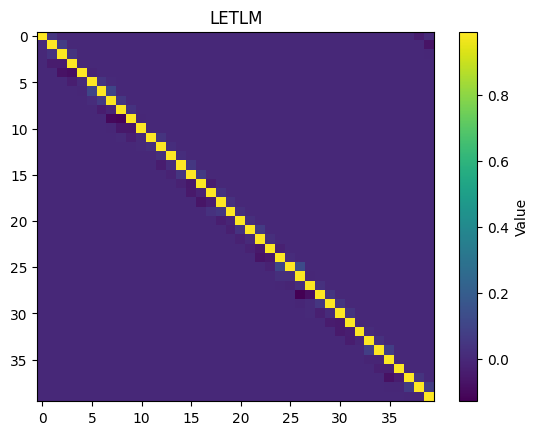

tensor([ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00, -1.9849e-05, -9.7846e-05, -1.5953e-02,  4.6382e-02,
         9.8911e-01,  6.3315e-02, -5.7442e-04,  3.1529e-06,  8.0175e-06,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00])


In [9]:
plt.imshow(LETLM,aspect='auto', cmap='viridis')
plt.colorbar(label='Value')
plt.title("LETLM")
plt.show()
print(LETLM[15])

In [15]:
# We will start by defining our error function
def norm_error(x_g,x_pert, model, M, model_parameters):
    (N, dx, dt, alpha, beta, F_L96) = model_parameters 
    x_in_pert = x_g + x_pert
    x_out_pert = model(x_in_pert, model_parameters)
    x_out_unpert = model(x_g, model_parameters)
    diff = x_out_pert - x_out_unpert - torch.matmul(M, x_pert)
    return diff


def normalisor(x_g, x_pert, model_parameters, M, model):
    x_in_pert = x_g + x_pert
    x_out_pert = model(x_in_pert, model_parameters)
    x_out_unpert = model(x_g, model_parameters)
    norm = x_out_pert - x_out_unpert
    return norm

def alt_TLM_test(x_g, x_pert, model_parameters, M, model):
    (N, dx, dt, alpha, beta, F_L96) = model_parameters 
    x_in_pert = x_g + x_pert
    x_out_pert = model(x_in_pert, model_parameters)
    x_out_unpert = model(x_g, model_parameters)
    diff = sum(abs(x_out_pert - x_out_unpert - torch.matmul(M, x_pert)))
    average = sum(abs(x_pert))
    return (diff/average)/N
    

# We will now define a very quick generic TLM test that will be used for the multistep TLM test 
def generic_TLM_test(diff, norm):
    error = math.sqrt(torch.matmul(diff.T, diff)/torch.matmul(norm.T, norm))
    return error

In [16]:
# We will now run the tests again and see if there is an increase in accuracy.
# We will now run the TLM test for a variety of different perturbation sizes
# we will start by defining the sizes of the perturbations
perturbations = [0,1,2,3,4,5,6,7,8,9,10]
results_local = []
trials = 50
spin_up_time = 1000

ensemble_size = 12
model = bf.rk4_L96
x_0 = torch.randn(N,1)
x = ETLMC.spin_up(x_0, model_parameters, model, spin_up_time)
x_g = x
for i in perturbations:
    sd = 10**(-1*perturbations[i])
    # We first need to spin up the model
    LETLM = LETLM_generator(ensemble_size, model_parameters, model, sd, spin_up_time, x_in = x_g)

    # we will now run the TLM test
    error = 0
    for j in range(trials):
        torch.manual_seed(j^2)
        x_pert = torch.randn(N,1) * sd
        # print(x_pert)

        diff = norm_error(x_g, x_pert, model, LETLM, model_parameters)
        norm = normalisor(x_g,x_pert, model_parameters, LETLM, model)
        # print(diff.shape)
        TLM_test_result = generic_TLM_test(diff, norm)
        error = alt_TLM_test(x_g, x_pert, model_parameters, LETLM, model)
    results_local.append(error/trials)

tensor([[-0.0027,  0.0084, -0.0126,  0.0114, -0.0054, -0.0062, -0.0094,  0.0021,
         -0.0078, -0.0059, -0.0031, -0.0053]])
tensor([[-0.0012, -0.0032,  0.0108, -0.0018,  0.0034,  0.0038,  0.0040, -0.0013,
          0.0024,  0.0062,  0.0029, -0.0037]])
tensor([[-0.0009, -0.0021,  0.0108, -0.0076,  0.0035,  0.0040,  0.0100, -0.0051,
          0.0116,  0.0092,  0.0019,  0.0006]])
tensor([[ 0.0029, -0.0093,  0.0037, -0.0074,  0.0033,  0.0018,  0.0100, -0.0033,
          0.0145,  0.0092,  0.0007, -0.0004]])
tensor([[ 0.0032,  0.0056, -0.0011, -0.0064, -0.0027,  0.0007,  0.0027,  0.0019,
         -0.0007,  0.0059,  0.0079,  0.0025]])
tensor([[ 5.3843e-04,  2.1182e-03, -5.1600e-03,  8.9829e-03,  3.3209e-04,
         -6.3048e-04, -1.7135e-03, -1.0151e-05,  1.5697e-03, -3.0248e-03,
         -5.2433e-03, -3.2726e-03]])
tensor([[-0.0075, -0.0007,  0.0061, -0.0028,  0.0066,  0.0013,  0.0111,  0.0003,
          0.0130,  0.0021,  0.0027, -0.0028]])
tensor([[ 2.7764e-03, -4.5069e-03,  1.2745e-03,

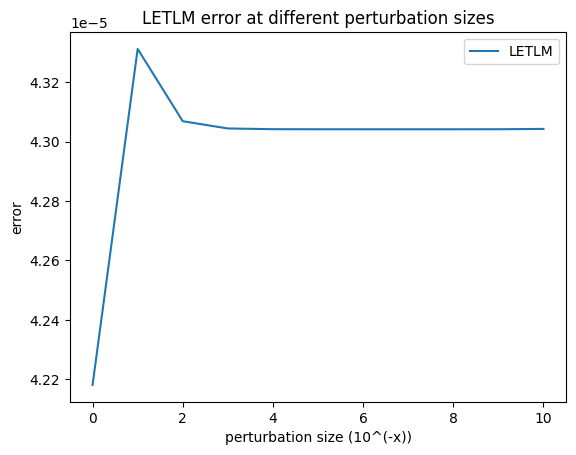

In [17]:
plt.plot(perturbations, results_local,label = 'LETLM' )

plt.xlabel('perturbation size (10^(-x))')
plt.ylabel('error')
plt.title('LETLM error at different perturbation sizes')
plt.legend()

plt.show()

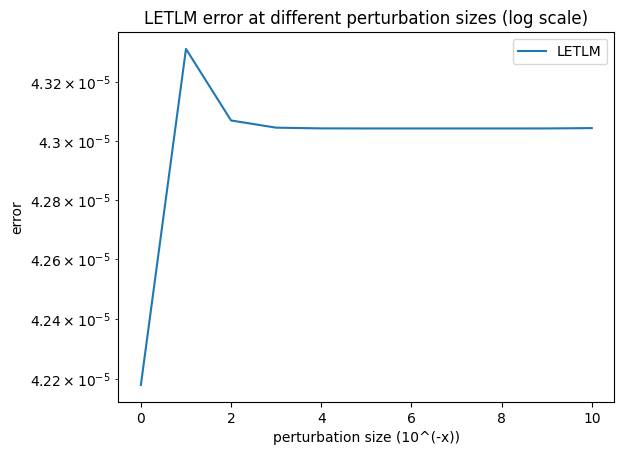

In [18]:
plt.yscale('log') # This is base 10
plt.plot(perturbations, results_local,label = 'LETLM' )

plt.xlabel('perturbation size (10^(-x))')
plt.ylabel('error')
plt.title('LETLM error at different perturbation sizes (log scale)')
plt.legend()

plt.show()